In [1]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
from featuregraph.behaviors.transition2 import Transition

from featuregraph.operators.states import (
    rising_state
)

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

Python: /workspaces/featuregraph/.venv/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [2]:
# create a transition object

In [3]:
diff_lag = 10
eps = 0.01

bidmc = fg.datasets.bidmc(subject=1)

bidmc_transition = Transition(
    bidmc,
    signal="respiration",
    direction='rising',
    op=rising_state,
    group="subject",
    diff_lag=diff_lag,
    eps=eps,
)

df = bidmc_transition.df
df['rate_of_change'] = df['respiration'].diff()
df['max_rate_of_change'] = df.groupby('respiration_id').transform('max')['rate_of_change']

(<Figure size 1600x660 with 3 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_id'>,
        <Axes: xlabel='Time', ylabel='respiration_rising_rate_of_change'>],
       dtype=object))

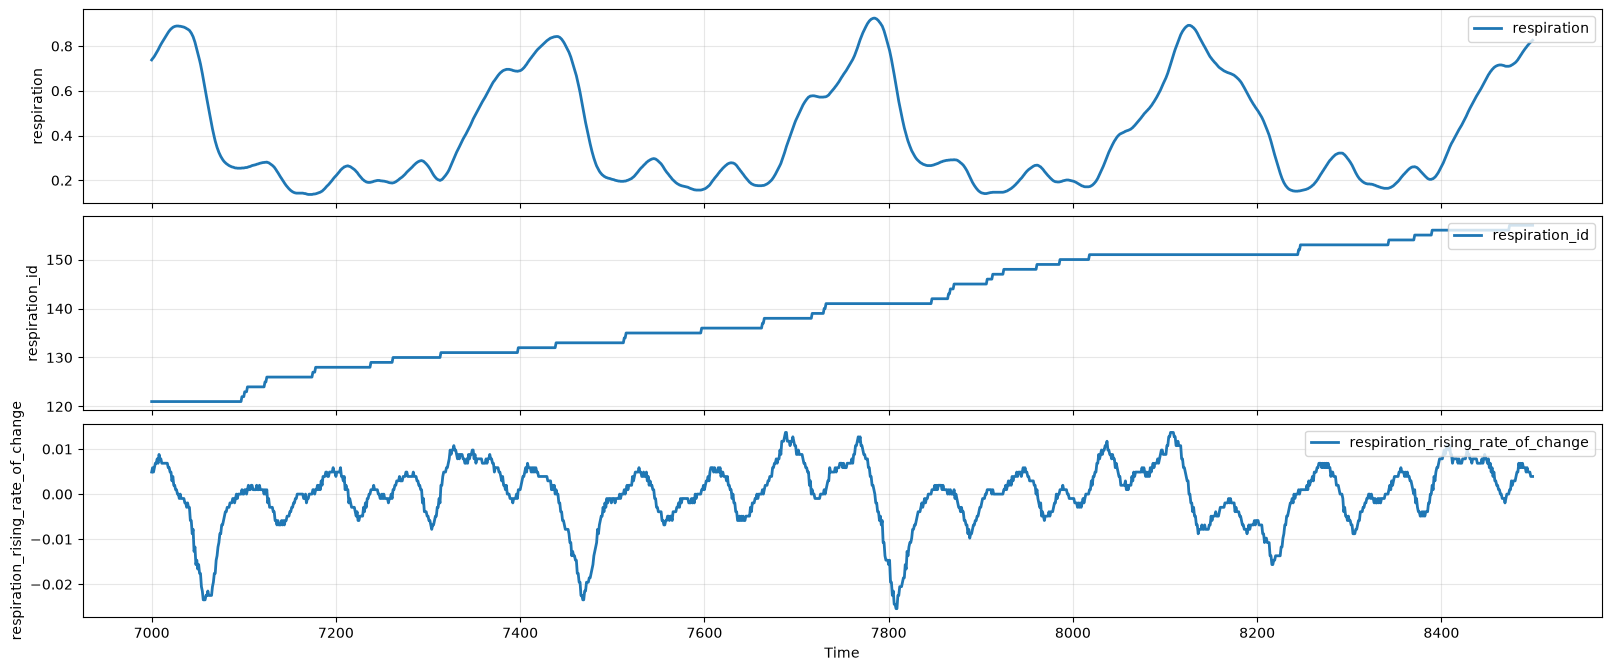

In [4]:
fg.plot(df[7000:8500], [['respiration'],
                            #   ['respiration_rising'],
                            #   ['enter_respiration_rising'],
                            #   ['exit_respiration_rising'],
                              ['respiration_id'],
                              ['respiration_rising_rate_of_change']
                             ]
)

In [5]:
summarydf = bidmc_transition.summary()

In [6]:
summarydf[50:80]

,duration,start_value,end_value,peak_rate_of_change,net_change,mean_rate
respiration_id,,,,,,
50,1,0.22287,0.11046,0.00097,-0.11241,-0.112410
51,8,0.11144,0.12317,0.00196,0.01173,0.001466
52,1,0.12414,0.11144,0.00097,-0.01270,-0.012700
53,104,0.11241,0.25024,0.01271,0.13783,0.001325
54,5,0.25122,0.25611,0.00196,0.00489,0.000978
55,1,0.25709,0.24829,0.00098,-0.00880,-0.008800
56,1,0.24927,0.24927,0.00098,0.00000,0.000000
57,1,0.25024,0.25024,0.00097,0.00000,0.000000
58,5,0.25122,0.25513,0.00098,0.00391,0.000782
